In [1]:
import os
import pandas as pd
import numpy as np

import pickle

import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, precision_recall_curve

import shap


import warnings
warnings.filterwarnings('ignore')

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


# Leitura dos artefatos

In [2]:
model = pickle.load(
    open('../models/wrapped/model_pipeline_prod.pkl', 'rb')
)
model


Pipeline(steps=[('json_to_df', Json parser),
                ('seletor_1',
                 Feature Selector. Mode: train. Features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'contact', 'contacts_tendency', 'default', 'emp.var.rate', 'employment_status', 'euribor3m', 'job', 'month', 'nr.employed', 'pdays', 'poutcome', 'previous', 'quarter', 'was_contacted_before']),
                ('cria_features', BuildFeatur...
                 Feature Selector. Mode: train. Features: ['age', 'campaign', 'cons.conf.idx', 'cons.price.idx', 'contact', 'contacts_tendency', 'default', 'emp.var.rate', 'employment_status', 'euribor3m', 'job', 'month', 'nr.employed', 'pdays', 'poutcome', 'previous', 'quarter', 'was_contacted_before']),
                ('modelo',
                 LGBMClassifier(eval_metric='auc',
                                learning_rate=0.026594346401661702, max_depth=6,
                                min_child_samples=95, n_estimators=304,
                                num_leaves=14, random_state=12))])

# Classificação de promoção

## Leitura das bases (treino e teste)

In [3]:
df_treino = pd.read_csv(os.path.join('..', 'data', 'train_test', 'train.csv'))

print(df_treino.shape)
df_treino.head()

(32940, 25)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,quarter,contacts_tendency,employment_status,was_contacted_before,y
0,31,admin.,single,university.degree,no,no,no,cellular,sep,fri,...,-3.4,92.379,-29.8,0.803,5017.5,3Q,0.0,employed,False,no
1,39,housemaid,married,high.school,no,yes,no,telephone,may,fri,...,1.1,93.994,-36.4,4.857,5191.0,2Q,0.0,employed,False,no
2,34,entrepreneur,married,professional.course,no,yes,no,cellular,jul,thu,...,1.4,93.918,-42.7,4.958,5228.1,3Q,0.0,employed,False,no
3,36,technician,married,basic.9y,unknown,no,no,telephone,may,tue,...,1.1,93.994,-36.4,4.856,5191.0,2Q,0.0,employed,False,no
4,25,student,single,unknown,unknown,yes,no,cellular,aug,fri,...,-2.9,92.201,-31.4,0.825,5076.2,3Q,0.0,not_employed,False,no


In [4]:
df_teste = pd.read_csv(os.path.join('..', 'data', 'train_test', 'test.csv'))

print(df_teste.shape)
df_teste.head()

(8236, 25)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,quarter,contacts_tendency,employment_status,was_contacted_before,y
0,27,student,single,high.school,unknown,yes,no,telephone,may,thu,...,1.1,93.994,-36.4,4.860,5191.0,2Q,0.0,not_employed,False,no
1,60,admin.,divorced,professional.course,no,yes,no,cellular,sep,wed,...,-1.1,94.199,-37.5,0.886,4963.6,3Q,1.0,employed,False,yes
2,51,blue-collar,married,high.school,no,no,no,telephone,may,fri,...,1.1,93.994,-36.4,4.855,5191.0,2Q,0.0,employed,False,no
3,39,blue-collar,single,unknown,unknown,no,no,telephone,may,mon,...,1.1,93.994,-36.4,4.857,5191.0,2Q,0.0,employed,False,no
4,35,blue-collar,married,basic.9y,unknown,no,no,telephone,may,fri,...,1.1,93.994,-36.4,4.864,5191.0,2Q,0.0,employed,False,no


In [5]:
seletor = pickle.load(
    open(os.path.join('..', 'models', 'encoders', 'seletor_2.pkl'), 'rb')
)

## Scoring

In [6]:
df_treino['score'] = model.predict_proba(df_treino)[:, 1]
df_teste['score'] = model.predict_proba(df_teste)[:, 1]

In [7]:
df_treino['y_pred'] = model.predict(df_treino)
df_teste['y_pred'] = model.predict(df_teste)

## Evaluation

In [8]:
df_treino['y_true'] = df_treino['y'].map({'no': 0, 'yes': 1})
df_teste['y_true'] = df_teste['y'].map({'no': 0, 'yes': 1})

In [9]:
report = classification_report(df_treino['y_true'], df_treino['y_pred'])
print(report)

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     29246
           1       0.70      0.28      0.40      3694

    accuracy                           0.91     32940
   macro avg       0.81      0.63      0.67     32940
weighted avg       0.89      0.91      0.89     32940



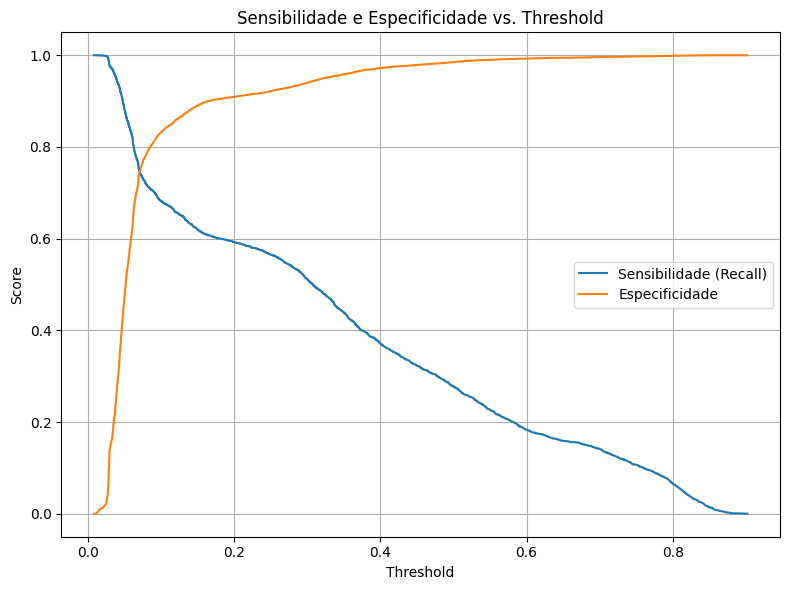

In [10]:
threshold_default = 0.5

df_treino['y_true'] = df_treino['y'].map({'no': 0, 'yes': 1})
df_treino['score'] = model.predict_proba(df_treino)[:, 1] 
df_treino['y_pred'] = (df_treino['score'] >= threshold_default).astype(int)


report = classification_report(df_treino['y_true'], df_treino['y_pred'], output_dict=True)
report_df = pd.DataFrame(report).transpose()

precision, recall, thresholds = precision_recall_curve(df_treino['y_true'], df_treino['score'])

specificity = []
for t in thresholds:
    y_pred_temp = (df_treino['score'] >= t).astype(int)
    tn = ((df_treino['y_true'] == 0) & (y_pred_temp == 0)).sum()
    fp = ((df_treino['y_true'] == 0) & (y_pred_temp == 1)).sum()
    specificity.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, recall[:-1], label='Sensibilidade (Recall)')
plt.plot(thresholds, specificity, label='Especificidade')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Sensibilidade e Especificidade vs. Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
youden_j = np.array(recall[:-1]) + np.array(specificity)

best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]
print(f'Melhor threshold (Youden): {best_threshold:.3f}')

Melhor threshold (Youden): 0.114


In [12]:
df_treino['y_pred_best'] = (df_treino['score'] >= best_threshold).astype(int)
report_best = classification_report(df_treino['y_true'], df_treino['y_pred_best'])
print(report_best)

              precision    recall  f1-score   support

           0       0.95      0.85      0.90     29246
           1       0.36      0.67      0.47      3694

    accuracy                           0.83     32940
   macro avg       0.66      0.76      0.68     32940
weighted avg       0.89      0.83      0.85     32940



In [13]:
df_teste['y_true'] = df_teste['y'].map({'no': 0, 'yes': 1})
df_teste['y_pred_best'] = (df_teste['score'] >= best_threshold).astype(int)

report_teste = classification_report(df_teste['y_true'], df_teste['y_pred_best'])
print(report_teste)

              precision    recall  f1-score   support

           0       0.95      0.85      0.89      7291
           1       0.35      0.64      0.45       945

    accuracy                           0.82      8236
   macro avg       0.65      0.74      0.67      8236
weighted avg       0.88      0.82      0.84      8236



In [17]:
roc_auc_score(
    df_treino['y'],
    df_treino['score']/100
)

0.8240039471013042

In [18]:
roc_auc_score(
    df_teste['y'],
    df_teste['score']/100
)

0.7971093592956164

In [21]:
importance = model[-1].feature_importances_

df_imp = pd.DataFrame({
    'feature': seletor.features,
    'imp': importance
}).sort_values(by='imp', ascending=False)


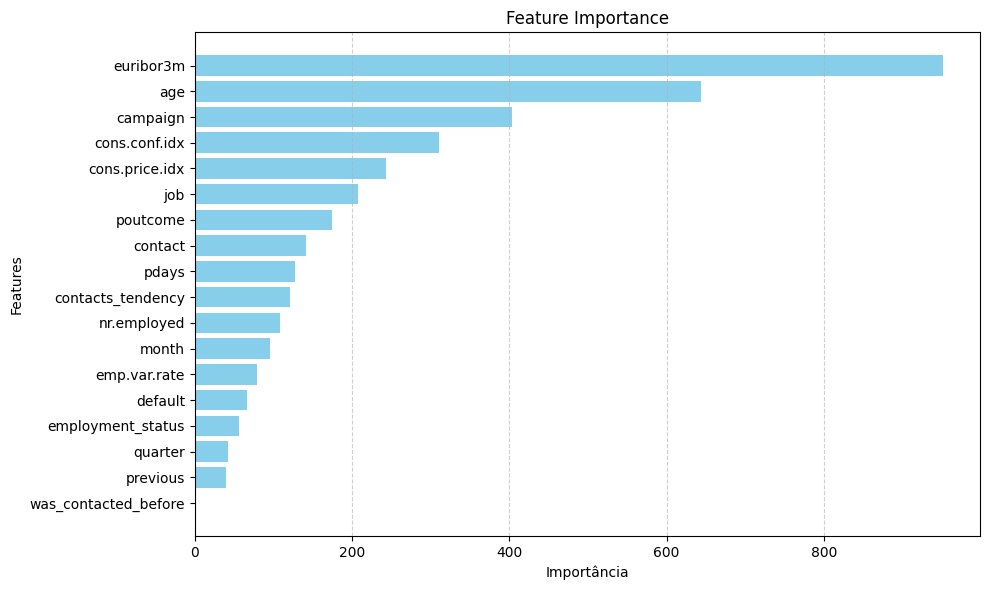

In [22]:
plt.figure(figsize=(10, 6))

plt.barh(df_imp['feature'], df_imp['imp'], color = 'skyblue')
plt.xlabel('Importância')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.grid(axis = 'x', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

In [23]:
df_treino_encoded = pd.read_csv(os.path.join('..', 'data', 'train_test', 'train_encoded.csv'))
sample_train = df_treino_encoded[seletor.features].sample(frac = 0.3, random_state=98)

 98%|===================| 9643/9882 [00:30<00:00]        

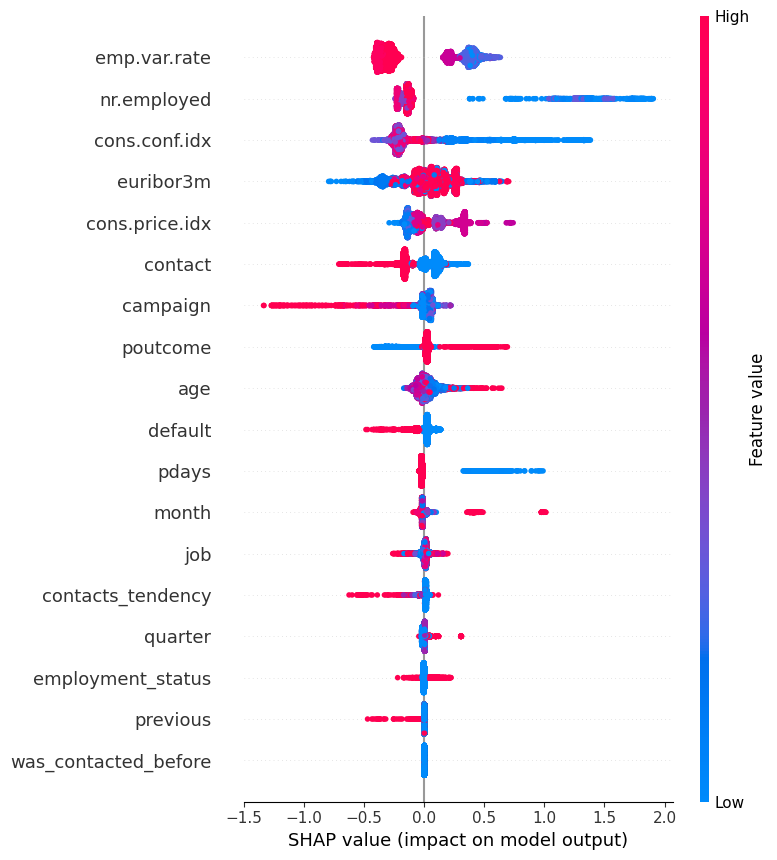

In [24]:
explainer = shap.Explainer(model[-1], sample_train)
shap_values = explainer(sample_train)

plt.figure(figsize = (10, 6))
shap.summary_plot(shap_values, sample_train)